# Lab 7.06 - Time series analysis

In [1]:
# Package Imports
import numpy as np                                  # Scientific computing
import pandas as pd                                 # Dataframe manipulation
import scipy.stats as stats                         # Statistical tests
import matplotlib.pyplot as plt                     # Basic visualization
import seaborn as sns                               # Advanced data visualization
from sklearn.linear_model import LinearRegression   # Linear regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose

## Exercise 6: COVID-19 data


In this lab assignment, we will make use of the COVID-19 dataset maintained by [Our World in Data](https://ourworldindata.org/coronavirus), published on Github at <https://github.com/owid/covid-19-data/tree/master/public/data>.

We took a snapshot of the data on 2023-05-31 that still contains *daily* observations. Recently, the dataset has been updated to only contain weekly observations.

First, we import the dataset, parse the `date` column as the Python `DateTime` type and set this as the index.

**Tip:** The CSV file is rather large, so instead you may want to load a local copy of the CSV file to avoid downloading it multiple times ('../data/owid-covid-data-2023-05-31.csv').

In [3]:
covid19 = pd.read_csv(
    'https://github.com/HoGentTIN/dsai-labs/raw/main/data/owid-covid-data-2023-05-31.csv',
    parse_dates=['date'],
    index_col=['date'])
covid19.head()

,iso_code,continent,location,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
date,,,,,,,,,,,,,,,,,,,,,
2020-01-03,AFG,Asia,Afghanistan,NaN,0.0,NaN,NaN,0.0,NaN,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2020-01-04,AFG,Asia,Afghanistan,NaN,0.0,NaN,NaN,0.0,NaN,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2020-01-05,AFG,Asia,Afghanistan,NaN,0.0,NaN,NaN,0.0,NaN,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2020-01-06,AFG,Asia,Afghanistan,NaN,0.0,NaN,NaN,0.0,NaN,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2020-01-07,AFG,Asia,Afghanistan,NaN,0.0,NaN,NaN,0.0,NaN,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN


Create a new `DataFrame` (with name e.g. `covid19_be`) that only contains the new cases in Belgium and use the `plot()` method of `DataFrame` to visualize it. Increase the size of the picture with the `figsize` parameter, otherwise it will be too small.

In [6]:
covid19_be = covid19[covid19['location'] == 'Belgium'][['new_cases']]
covid19_be.head()

,new_cases
date,
2020-01-03,0.0
2020-01-04,0.0
2020-01-05,0.0
2020-01-06,0.0
2020-01-07,0.0


<Axes: xlabel='date'>

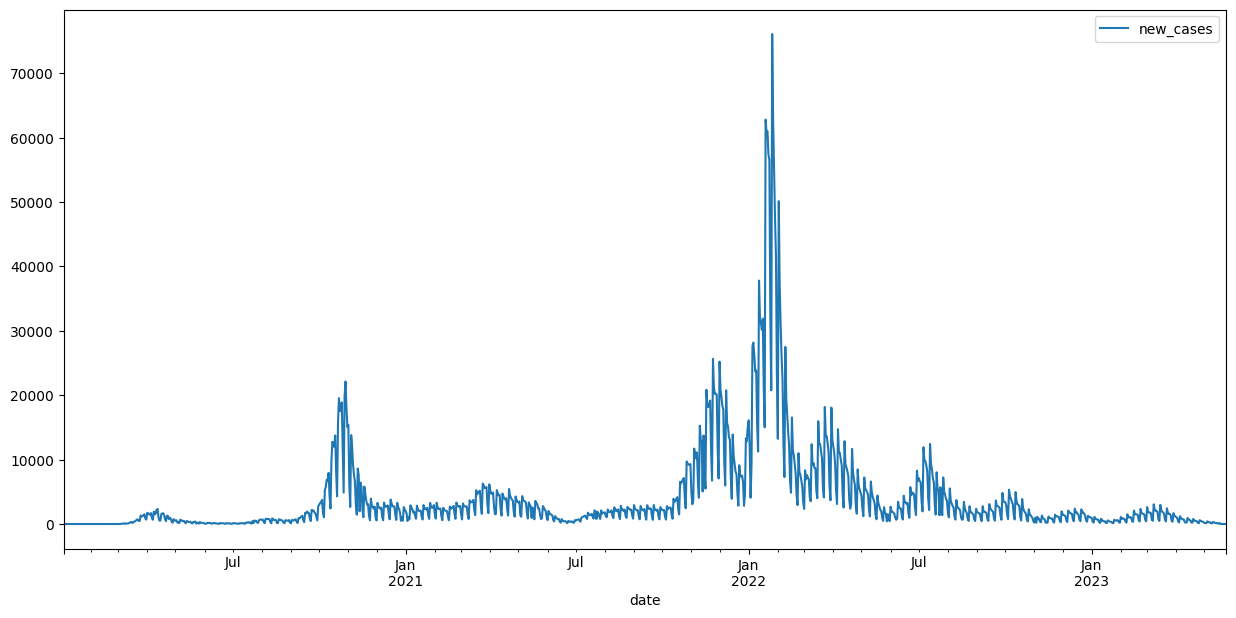

In [9]:
covid19_be.plot(y=['new_cases'], figsize=[15,7])

### Moving average

Add new columns to the data frame with new cases in Belgium with the simple moving average for 7 and 30 days. Plot the entire data frame (observations and both moving averages).

In [11]:
# Calculate valid lagging predictions using shift(1)
covid19_be['SMA7'] = covid19_be['new_cases'].rolling(7).mean().shift(1)
covid19_be['SMA30'] = covid19_be['new_cases'].rolling(30).mean().shift(1)
covid19_be.head(10)

,new_cases,SMA7,SMA30
date,,,
2020-01-03,0.0,NaN,NaN
2020-01-04,0.0,NaN,NaN
2020-01-05,0.0,NaN,NaN
2020-01-06,0.0,NaN,NaN
2020-01-07,0.0,NaN,NaN
2020-01-08,0.0,NaN,NaN
2020-01-09,0.0,NaN,NaN
2020-01-10,0.0,0.0,NaN
2020-01-11,0.0,0.0,NaN


<Axes: xlabel='date'>

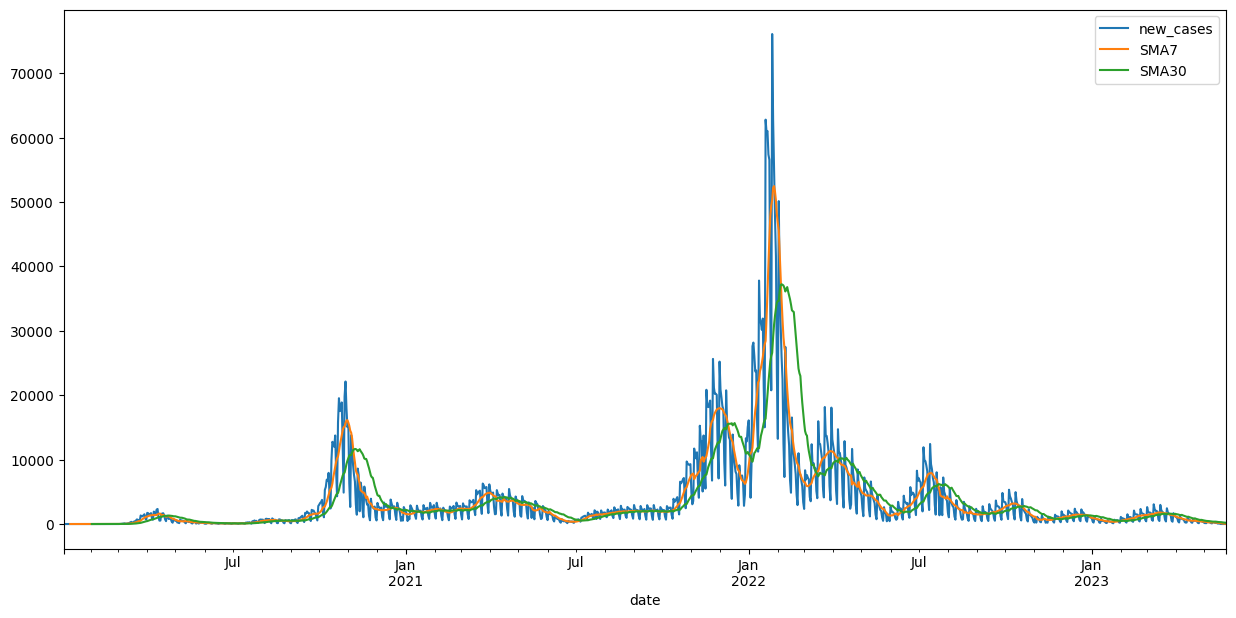

In [12]:
covid19_be.plot(y=['new_cases', 'SMA7', 'SMA30'], figsize=[15,7])

### Holt-Winters model for new cases early 2021

The period from about December 2020 up to the end of February 2021 seems quite regular. Create a new `DataFrame` and select only the observations during that period (1 December 2020 to 28 February 2021). Plot the `DataFrame` (it will still contain the moving averages from the previous step).

<Axes: xlabel='date'>

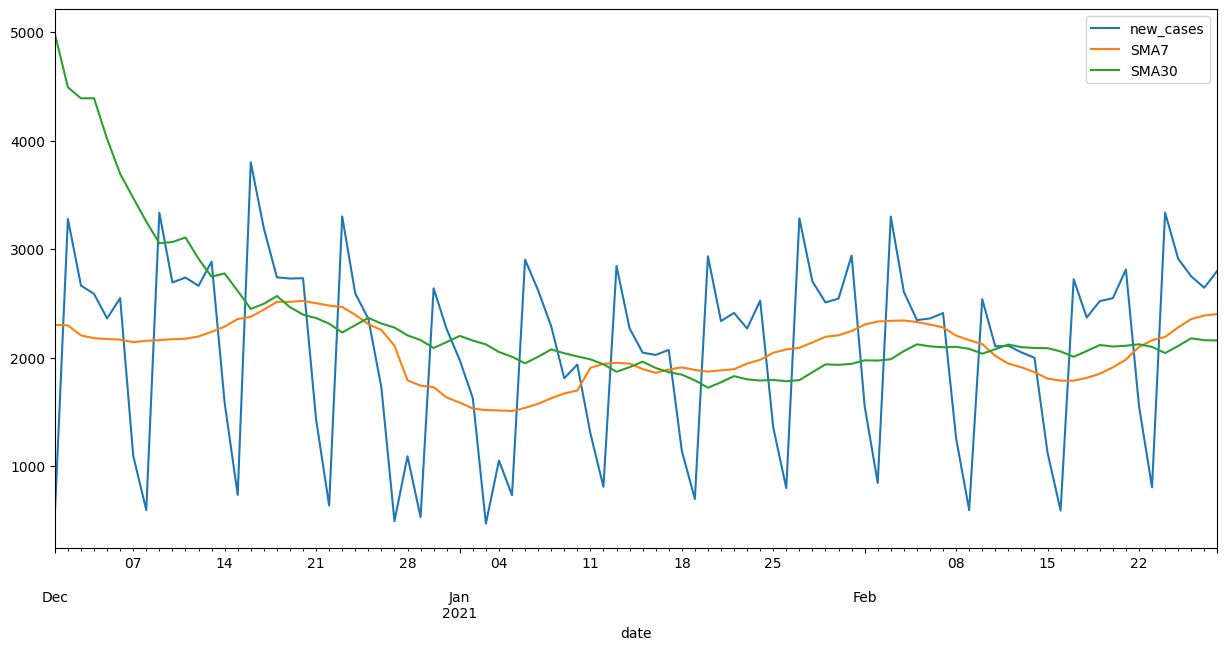

In [17]:
sample = covid19_be['2020-12-01':'2021-02-28']
sample.plot(y=['new_cases', 'SMA7', 'SMA30'], figsize=[15,7])



Build a Holt-Winters model for the observed new cases during that period.

Use the additive type for both trend and seasonal smoothing. Set the value for `seasonal_periods` to the appropriate value! Plot the observed and fitted values.

In [22]:
data_tes = ExponentialSmoothing(sample['new_cases'], trend='add', seasonal='add', seasonal_periods=7, freq='D').fit()
sample['TES'] = data_tes.fittedvalues
sample.head()

,new_cases,SMA7,SMA30,TES
date,,,,
2020-12-01,553.0,2300.428571,4985.400000,728.205825
2020-12-02,3277.0,2296.285714,4490.266667,3061.623975
2020-12-03,2663.0,2203.571429,4388.933333,2621.986423
2020-12-04,2587.0,2178.142857,4389.533333,2490.734221
2020-12-05,2360.0,2170.000000,4015.600000,2374.620568


<Axes: xlabel='date'>

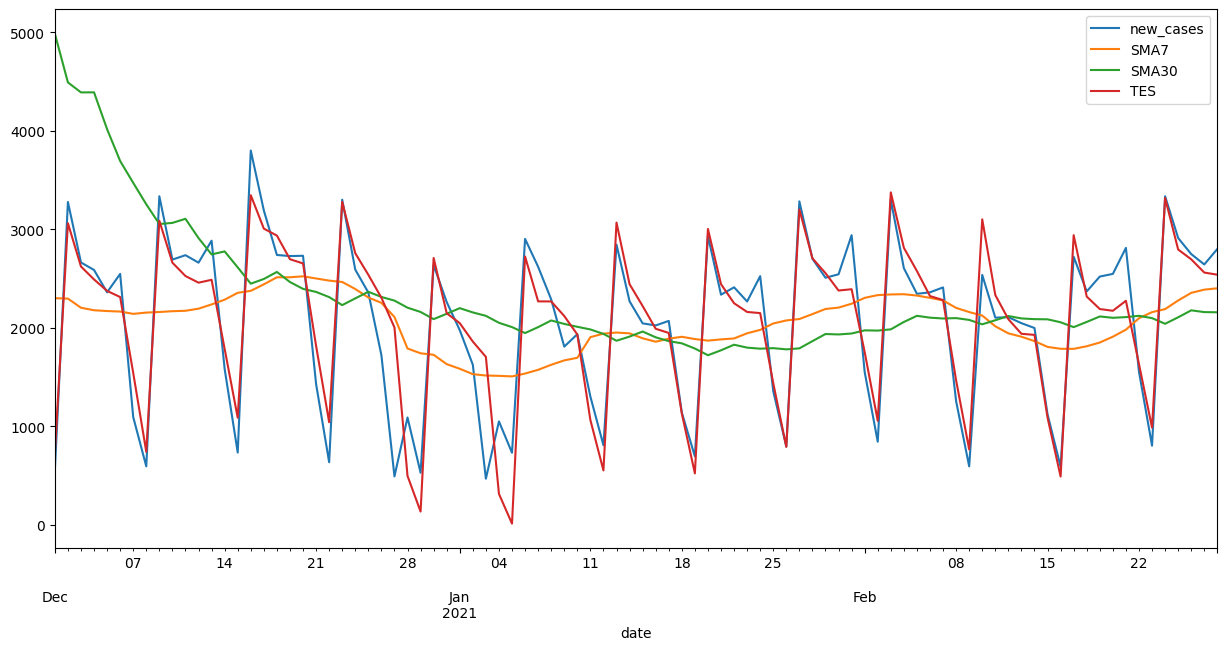

In [29]:
sample.plot(y=['new_cases', 'SMA7', 'SMA30', 'TES'], figsize=[15,7])

Now, make a forecast for 21 days and plot observed and forecasted values. What do you notice when you compare observed and forecasted values as time progresses?

In [37]:
observed = covid19_be['2021-03-01':'2021-03-21']
observed['forecast'] = data_tes.forecast(21)

<Axes: xlabel='date'>

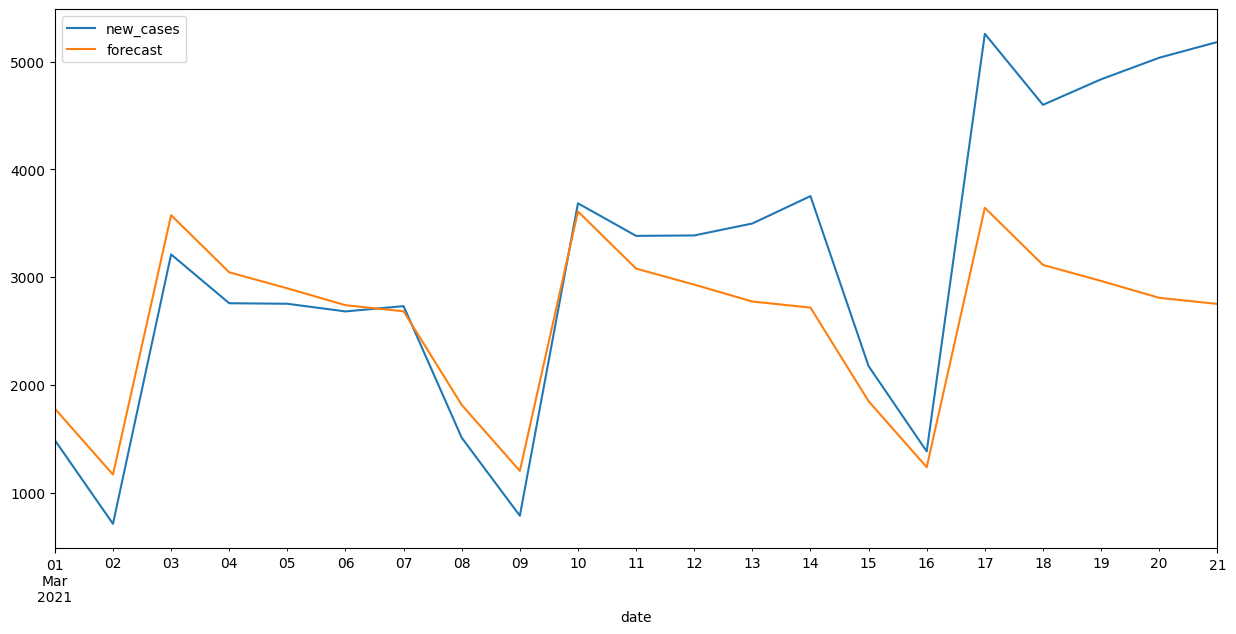

In [38]:
observed.plot(y=['new_cases', 'forecast'], figsize=[15,7])

### Evaluating model quality


- Calculate the Mean Squared Error for a forecast period of 7 days, and compare its square root with the standard deviation of observed new cases over the test period and forecasted period combined.
- Do the same for a forecast period of 14 and 21 days.
- For which period is the quality of the forecast ok?

The expected results are shown in the table below:

|     Forecast period      |         MSE |     √MSE |    stdev |
| :----------------------: | ----------: | -------: | -------: |
| 2021-03-01 to 2021-03-07 |   25408.902 |  159.402 |  855.684 |
| 2021-03-01 to 2021-03-14 |  154280.817 |  392.786 |  895.531 |
| 2021-03-01 to 2021-03-21 | 1048835.781 | 1024.127 | 1052.978 |

In [44]:
data_tes.forecast(21).values[:7]

array([1779.99077141, 1168.05718312, 3575.35549814, 3044.89895449,
       2896.35229478, 2739.64563188, 2683.22163802])

In [46]:
y_true1 = covid19_be['2021-03-01':'2021-03-07']['new_cases'].values
y_true2 = covid19_be['2021-03-01':'2021-03-14']['new_cases'].values
y_true3 = covid19_be['2021-03-01':'2021-03-21']['new_cases'].values
y_predicted = data_tes.forecast(21).values
y_predicted1 = y_predicted[:7]
y_predicted2 = y_predicted[:14]
y_predicted3 = y_predicted[:21]
mse1 = mean_squared_error(y_true1, y_predicted1)
mse2 = mean_squared_error(y_true2, y_predicted2)
mse3 = mean_squared_error(y_true3, y_predicted3)
print(f"MSE1 = {mse1}")
print(f"MSE2 = {mse2}")
print(f"MSE3 = {mse3}")

MSE1 = 76566.63872161982
MSE2 = 193064.87398340125
MSE3 = 1048358.8951890114


### ICU patients

Create a new `DataFrame` with only the total number of ICU (intensive care units) patients in the Belgian hospitals. Make sure that all NaN's are removed, since time series analysis functions can't cope with missing values. Plot this time series. 

In [83]:
icu_be = covid19[covid19['location'] == 'Belgium'][['icu_patients']].dropna().asfreq('D')

<Axes: xlabel='date'>

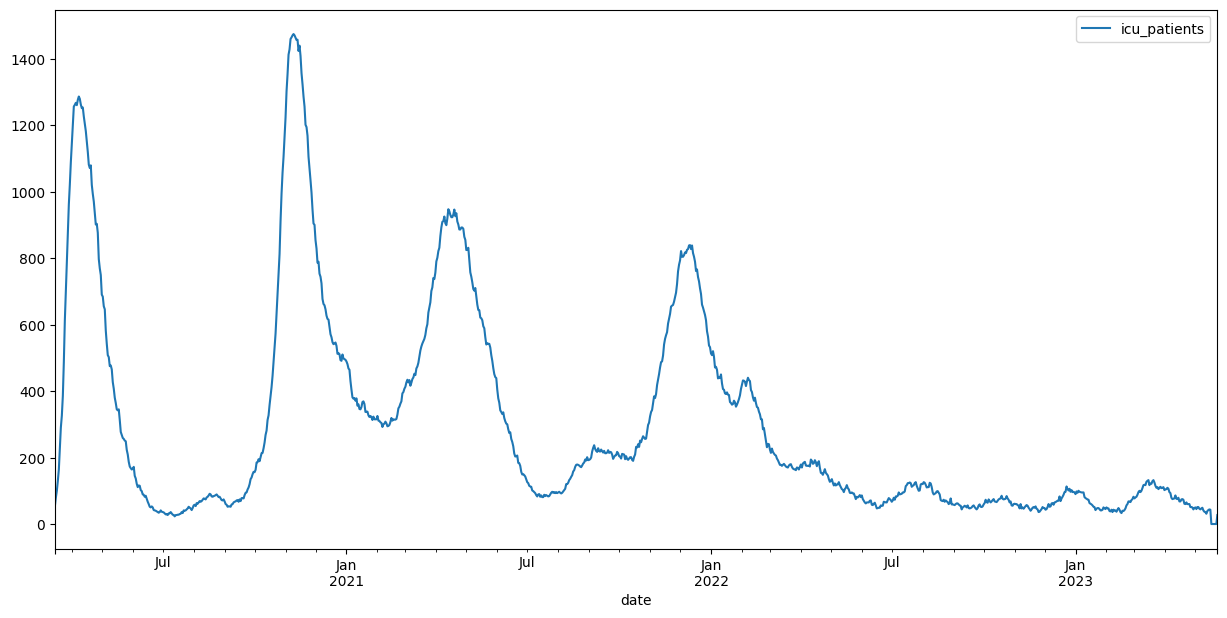

In [84]:
icu_be.plot(y=['icu_patients'], figsize=[15,7])

Build a double exponential smoothing (Holt) model of this time series. Make a forecast of 70 time units and plot the observations, fitted values and forecast.

Are we currently in an upward or downward trend, according to this model? Do the forecasted values seem reasonable if you look at the last period?

In [85]:
data_des = Holt(icu_be['icu_patients']).fit()
data_des_forecast = data_des.forecast(70)

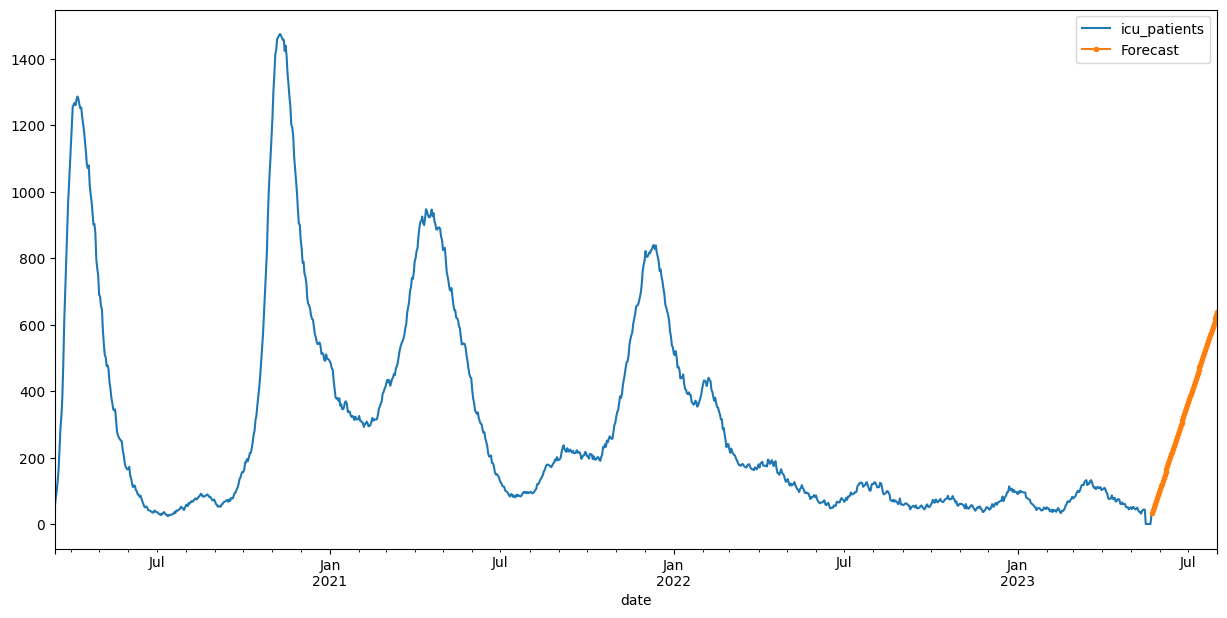

In [86]:
icu_be.plot(y=['icu_patients'], figsize=[15,7])
data_des_forecast.plot(marker='.', legend=True, label='Forecast');

Since we didn't set any initial parameters like $\alpha$ and $\beta$, the model calculated them using some rule of thumb. List these parameters from the model:

In [87]:
data_des.params_formatted

,name,param,optimized
smoothing_level,alpha,0.958466,True
smoothing_trend,beta,0.373023,True
initial_level,l.0,53.000000,False
initial_trend,b.0,26.000000,False


What were the final estimated values for the level and trend, that are used in the forecast? In other words, what are the parameters of the line that estimates future observations?

In [88]:
print(f"Last level: {data_des.level.iloc[-1]}")
print(f"Last trend: {data_des.trend.iloc[-1]}")
print(f"Line Equation: ŷ_(t+k) = {data_des.level.iloc[-1]} + ({data_des.trend.iloc[-1]}) * k")

Last level: 25.812017521613768
Last trend: 8.73148571103426
Line Equation: ŷ_(t+k) = 25.812017521613768 + (8.73148571103426) * k


Let's try to set the parameters ourselves. Recreate the Holt-model with $\alpha = \beta = 0.1$. Calculate a forecast like before and plot.

In [89]:
data_des = Holt(icu_be['icu_patients']).fit(smoothing_level=0.1, smoothing_trend=0.1, optimized=False)
data_des_forecast = data_des.forecast(70)

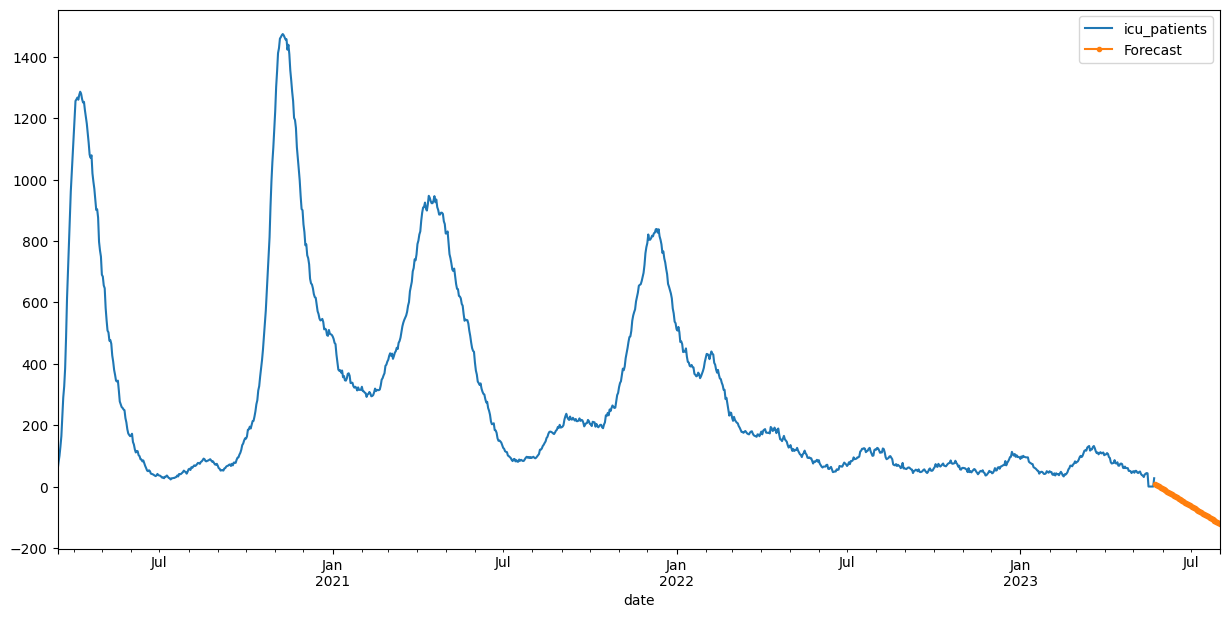

In [90]:
icu_be.plot(y=['icu_patients'], figsize=[15,7])
data_des_forecast.plot(marker='.', legend=True, label='Forecast');

Compare the model parameters and final estimates. Which of the two forecast models seems to perform best if you look at the plots?

In [92]:
data_des.params_formatted

,name,param,optimized
smoothing_level,alpha,0.1,False
smoothing_trend,beta,0.1,False
initial_level,l.0,53.0,False
initial_trend,b.0,26.0,False


In [91]:
print(f"Last level: {data_des.level.iloc[-1]}")
print(f"Last trend: {data_des.trend.iloc[-1]}")
print(f"Line Equation: ŷ_(t+k) = {data_des.level.iloc[-1]} + ({data_des.trend.iloc[-1]}) * k")

Last level: 9.91537669812055
Last trend: -1.8855731983284
Line Equation: ŷ_(t+k) = 9.91537669812055 + (-1.8855731983284) * k
